Model Training

In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned_survey.csv")

In [2]:
df["treatment"] = df["treatment"].map({
    "No": 0,
    "Yes": 1
})

df_model = df.drop(
    columns=["Timestamp", "comments"]
)

df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

from sklearn.model_selection import train_test_split

X = df_model.drop("treatment", axis=1)
y = df_model["treatment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Checking accuracy

In [4]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.832


Classification Report

In [5]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82       124
           1       0.81      0.87      0.84       126

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250



Confusion Matrix

In [6]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[ 98  26]
 [ 16 110]]


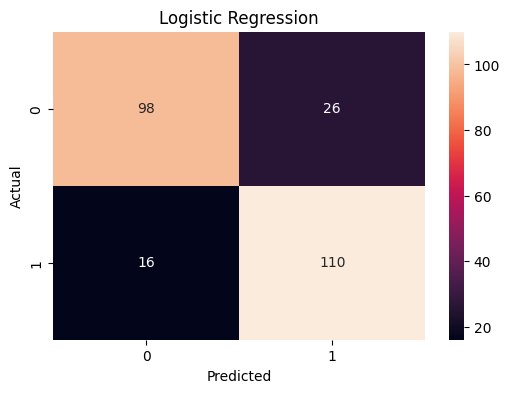

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

2. Naive Bayes

In [8]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.48      0.09      0.15       124
           1       0.50      0.90      0.65       126

    accuracy                           0.50       250
   macro avg       0.49      0.50      0.40       250
weighted avg       0.49      0.50      0.40       250



3. SVM

In [9]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.704
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       124
           1       0.72      0.67      0.70       126

    accuracy                           0.70       250
   macro avg       0.70      0.70      0.70       250
weighted avg       0.70      0.70      0.70       250



Model Comparison

In [10]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                 Model  Accuracy
0  Logistic Regression     0.832
2                  SVM     0.704
1          Naive Bayes     0.500


## Best Model Selection

Among the three models tested, Logistic Regression achieved the highest accuracy of 83.2%.

Therefore, Logistic Regression was selected as the final model for predicting whether an employee is likely to seek mental health treatment.

In [12]:
import joblib

joblib.dump(
    lr,
    "../models/mental_health_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
